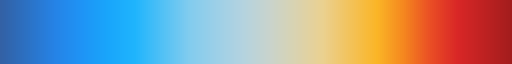

In [1]:
%load_ext autoreload
%autoreload 2
import os
os.chdir("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/IPC")
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import sparse
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap

# Gradient colormap
exp_colors = ["#EDEDED", "#FFF7F3","#F7FCF0","#E0F3DB","#CCEBC5","#7BCCC4","#4EB3D3","#2B8CBE","#0868AC","#084081"]
exp_cmap = LinearSegmentedColormap.from_list("my_cmap", exp_colors, N=256)
exp_cmap

acc_colors = ["#EDEDED", "#fddfdb","#edb8b0","#e69191","#c25759"]
acc_cmap = LinearSegmentedColormap.from_list("my_cmap", acc_colors, N=256)
acc_cmap

RNA_colors = ["#352A86", "#343296", "#343AA7", "#2646BB", "#1156D0", "#0366DE", "#0A76D8", "#1286D2", "#1C99C0", "#27ADAC", "#46B897", "#78BB7E", "#A9BD67", "#CCBC57", "#EFBA47", "#F7C438", "#F6D12B", "#F6DF1F", "#F7EC16", "#F8FA0D"]
RNA_cmap = LinearSegmentedColormap.from_list("my_cmap", RNA_colors, N=256)
RNA_cmap

ATAC_colors = ["#3361A5", "#2C72C5", "#2683E6", "#1F94F6", "#19A6FB", "#20B5FD", "#51C1F6", "#81CCEF", "#9CD0E8", "#B4D3E0", "#C9D4CD", "#DAD3B0", "#EBD190", "#F3C35B", "#FBB627", "#F5871F", "#EA4E25", "#D92727", "#BE2222", "#A31D1D"]
ATAC_cmap = LinearSegmentedColormap.from_list("my_cmap", ATAC_colors, N=256)
ATAC_cmap

# Plot Gene-Peak links on trajectory

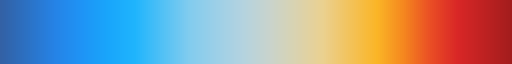

In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap

RNA_colors = ["#352A86", "#343296", "#343AA7", "#2646BB", "#1156D0", "#0366DE", "#0A76D8", "#1286D2", "#1C99C0", "#27ADAC", "#46B897", "#78BB7E", "#A9BD67", "#CCBC57", "#EFBA47", "#F7C438", "#F6D12B", "#F6DF1F", "#F7EC16", "#F8FA0D"]
RNA_cmap = LinearSegmentedColormap.from_list("my_cmap", RNA_colors, N=256)
RNA_cmap

ATAC_colors = ["#3361A5", "#2C72C5", "#2683E6", "#1F94F6", "#19A6FB", "#20B5FD", "#51C1F6", "#81CCEF", "#9CD0E8", "#B4D3E0", "#C9D4CD", "#DAD3B0", "#EBD190", "#F3C35B", "#FBB627", "#F5871F", "#EA4E25", "#D92727", "#BE2222", "#A31D1D"]
ATAC_cmap = LinearSegmentedColormap.from_list("my_cmap", ATAC_colors, N=256)
ATAC_cmap

In [3]:
import mudata
scplus_mdata = mudata.read("outs/scplusmdata.h5mu")
scplus_mdata

MuData object with n_obs × n_vars = 11745 × 206822
  uns:	'direct_e_regulon_metadata', 'extended_e_regulon_metadata'
  6 modalities
    scRNA_counts:	11745 x 36601
      obs:	'sample2', 'barcode2', 'celltype'
      var:	'gene_ids', 'feature_types'
    scATAC_counts:	11745 x 169879
      obs:	'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc', 'sample_id', 'sample2', 'barcode2', 'celltype'
      var:	'Chromosome', 'Start', 'End', 'Width', 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc'
    direct_gene_based_AUC:	11745 x 98
    direct_region_based_AUC:	11745 x 98
    extended_gene_based_AUC:	11745 x 73
    extended_region_based_AUC:	11745 x 73

In [4]:
adata_rna = scplus_mdata.mod['scRNA_counts']
adata_rna.obs['group'] = adata_rna.obs['sample2'].astype(str) + '_' + adata_rna.obs['barcode2'].astype(str)
adata_rna

AnnData object with n_obs × n_vars = 11745 × 36601
    obs: 'sample2', 'barcode2', 'celltype', 'group'
    var: 'gene_ids', 'feature_types'

In [5]:
adata_atac = scplus_mdata.mod['scATAC_counts']
adata_atac.obs['group'] = adata_atac.obs['sample2'].astype(str) + '_' + adata_atac.obs['barcode2'].astype(str)
adata_atac

AnnData object with n_obs × n_vars = 11745 × 169879
    obs: 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc', 'sample_id', 'sample2', 'barcode2', 'celltype', 'group'
    var: 'Chromosome', 'Start', 'End', 'Width', 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc'

In [6]:
adata_atac.obs

,cisTopic_nr_frag,cisTopic_log_nr_frag,cisTopic_nr_acc,cisTopic_log_nr_acc,sample_id,sample2,barcode2,celltype,group
AGTAACACATAATCGT-1-2___cisTopic,11696,4.068037,6377,3.804616,cisTopic,GW7,AGTAACACATAATCGT-1,NPC,GW7_AGTAACACATAATCGT-1
CCTTCGGTCCTCCCTC-1-6___cisTopic,790,2.897627,477,2.678518,cisTopic,GW17,CCTTCGGTCCTCCCTC-1,OPC,GW17_CCTTCGGTCCTCCCTC-1
TACTGAGGTAAAGCAA-1-5___cisTopic,4839,3.684756,2778,3.443732,cisTopic,GW16,TACTGAGGTAAAGCAA-1,OPC,GW16_TACTGAGGTAAAGCAA-1
GTATTGCAGGAGCAAC-1-6___cisTopic,8696,3.939320,4966,3.696007,cisTopic,GW17,GTATTGCAGGAGCAAC-1,OPC,GW17_GTATTGCAGGAGCAAC-1
TTTAAGCCATTGCAGC-1-6___cisTopic,3453,3.538197,2071,3.316180,cisTopic,GW17,TTTAAGCCATTGCAGC-1,OPC,GW17_TTTAAGCCATTGCAGC-1
...,...,...,...,...,...,...,...,...,...
AGCTAGTTCATCACTT-1-4___cisTopic,10551,4.023294,5949,3.774444,cisTopic,GW10,AGCTAGTTCATCACTT-1,IPC,GW10_AGCTAGTTCATCACTT-1
CCTACTTCATGCTTAG-1-7___cisTopic,4973,3.696618,3073,3.487563,cisTopic,GW20,CCTACTTCATGCTTAG-1,OPC,GW20_CCTACTTCATGCTTAG-1
GGGAGTAGTTAAGTGT-1-5___cisTopic,2956,3.470704,1771,3.248219,cisTopic,GW16,GGGAGTAGTTAAGTGT-1,IPC,GW16_GGGAGTAGTTAAGTGT-1
TTACCGTGTCACACCC-1-2___cisTopic,7490,3.874482,4327,3.636187,cisTopic,GW7,TTACCGTGTCACACCC-1,NPC,GW7_TTACCGTGTCACACCC-1


In [7]:
import pandas as pd
import numpy as np
import ast 

region_to_gene = pd.read_csv("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/IPC/outs/region_to_gene_adj.tsv",sep = '\t')
region_df = region_to_gene.copy()
# prepare the distance column
def parse_distance(x):
    if isinstance(x, str):
        try:
            return abs(ast.literal_eval(x)[0])
        except:
            return 999999999
    elif isinstance(x, list):
        return abs(x[0])
    return abs(x)

region_df['abs_distance'] = region_df['Distance'].apply(parse_distance)

# set the filtering threshold
# condition 1: must be positively correlated (Open chromatin -> Gene Expression)
# set a slightly higher threshold 0.03, filter out very weak correlations
cond_rho = region_df['rho'] > 0.03 

# condition 2: Importance must be high
# strategy: take the 50th percentile of Importance (keep top 50% strong connections)
importance_cutoff = region_df['importance'].quantile(0.5)
cond_imp = region_df['importance'] > importance_cutoff

# condition 3: distance should not be too far
cond_dist = region_df['abs_distance'] < 500000


# filtering
region_filtered = region_df[cond_rho & cond_imp & cond_dist].copy()
print(f"original number of connections: {len(region_df)}")
print(f"number of connections after filtering: {len(region_filtered)}")

# preview
region_filtered.head()

original number of connections: 476976
number of connections after filtering: 68700


,target,region,importance,rho,importance_x_rho,importance_x_abs_rho,Distance,abs_distance
20,A2ML1,chr12:8844630-8845131,0.108673,0.145178,0.015777,0.015777,[0],0
21,A2ML1,chr12:8687707-8688208,0.063232,0.125106,0.007911,0.007911,[134663],134663
22,A2ML1,chr12:8682012-8682513,0.030242,0.066073,0.001998,0.001998,[140359],140359
23,A2ML1,chr12:8949482-8949983,0.057007,0.052771,0.003008,0.003008,[-62731],62731
24,A2ML1,chr12:8828666-8829167,0.073730,0.167769,0.012370,0.012370,[0],0


In [8]:
barcode_groups = pd.read_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/IPC/seq2print/barcode_groups_latent_time_based.csv', sep=',', header=0)[['barcode','group']]
barcode_groups

,barcode,group
0,GW7_AGTTGCGTCCGTAAAC-1,ExN_ExN_naive_pbulk_1
1,GW7_GAAGTATAGGATTGAG-1,ExN_ExN_naive_pbulk_1
2,GW7_GGCCAACTCTAATTGG-1,ExN_ExN_naive_pbulk_1
3,GW7_TTCCTCAAGCGAGTAA-1,ExN_ExN_naive_pbulk_1
4,GW7_AATCATGTCACTTCAT-1,ExN_ExN_naive_pbulk_1
...,...,...
49674,GW16_GTGTAACTCAATTGGC-1,Astro_NPC_pbulk_5
49675,GW9_ATAACGACATTGCGAC-1,Astro_NPC_pbulk_5
49676,GW16_GATAATCGTGTTGCAA-1,Astro_NPC_pbulk_5
49677,GW16_TCACCTCAGTAGGCGG-1,Astro_NPC_pbulk_5


In [9]:
# 1. Pseudobulk column order for three lineages
exn_order = [
    'ExN_NPC_pbulk_1', 'ExN_NPC_pbulk_2', 'ExN_NPC_pbulk_3', 'ExN_NPC_pbulk_4', 'ExN_NPC_pbulk_5', 'ExN_NPC_pbulk_6', 'ExN_NPC_pbulk_7',
    'ExN_IPC_pbulk_1', 'ExN_IPC_pbulk_2', 'ExN_IPC_pbulk_3', 'ExN_IPC_pbulk_4',
    'ExN_ExN_naive_pbulk_1', 'ExN_ExN_naive_pbulk_2', 'ExN_ExN_naive_pbulk_3', 'ExN_ExN_naive_pbulk_4', 'ExN_ExN_naive_pbulk_5', 'ExN_ExN_naive_pbulk_6', 'ExN_ExN_naive_pbulk_7', 'ExN_ExN_naive_pbulk_8', 'ExN_ExN_naive_pbulk_9'
]

inn_order = [
    'InN_NPC_pbulk_1', 'InN_NPC_pbulk_2', 'InN_NPC_pbulk_3', 'InN_NPC_pbulk_4', 'InN_NPC_pbulk_5', 'InN_NPC_pbulk_6', 'InN_NPC_pbulk_7', 'InN_NPC_pbulk_8', 
    'InN_IPC_pbulk_1', 'InN_IPC_pbulk_2', 'InN_IPC_pbulk_3', 'InN_IPC_pbulk_4', 'InN_IPC_pbulk_5', 'InN_IPC_pbulk_6', 'InN_IPC_pbulk_7', 'InN_IPC_pbulk_8',
    'InN_InN_naive_pbulk_1', 'InN_InN_naive_pbulk_2', 'InN_InN_naive_pbulk_3', 'InN_InN_naive_pbulk_4'
]

oligo_order = [
    'Oligo_NPC_pbulk_1', 'Oligo_NPC_pbulk_2', 'Oligo_NPC_pbulk_3',
    'Oligo_IPC_pbulk_1', 'Oligo_IPC_pbulk_2', 'Oligo_IPC_pbulk_3',
    'Oligo_OPC_pbulk_1', 'Oligo_OPC_pbulk_2', 'Oligo_OPC_pbulk_3', 'Oligo_OPC_pbulk_4', 'Oligo_OPC_pbulk_5', 'Oligo_OPC_pbulk_6', 'Oligo_OPC_pbulk_7', 'Oligo_OPC_pbulk_8', 'Oligo_OPC_pbulk_9', 'Oligo_OPC_pbulk_10', 'Oligo_OPC_pbulk_11', 'Oligo_OPC_pbulk_12', 'Oligo_OPC_pbulk_13', 'Oligo_OPC_pbulk_14'
]

astro_order = [
    'Astro_NPC_pbulk_1', 'Astro_NPC_pbulk_2', 'Astro_NPC_pbulk_3', 'Astro_NPC_pbulk_4', 'Astro_NPC_pbulk_5',
    'Astro_IPC_pbulk_1',
    'Oligo_OPC_pbulk_1', 'Oligo_OPC_pbulk_2', 'Oligo_OPC_pbulk_3', 'Oligo_OPC_pbulk_4', 'Oligo_OPC_pbulk_5', 'Oligo_OPC_pbulk_6', 'Oligo_OPC_pbulk_7', 'Oligo_OPC_pbulk_8', 'Oligo_OPC_pbulk_9', 'Oligo_OPC_pbulk_10', 'Oligo_OPC_pbulk_11', 'Oligo_OPC_pbulk_12', 'Oligo_OPC_pbulk_13', 'Oligo_OPC_pbulk_14'
]

lineage_dict = {
    'ExN': exn_order,
    'InN': inn_order,
    'Oligo': oligo_order,
    'Astro': astro_order
}

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore, pearsonr
from scipy.ndimage import gaussian_filter1d
import os

# 2. Lineage-specific link filter
# ==========================================
def get_lineage_specific_links(global_links, rna_df, atac_df, lineage_cols, min_corr=0.25):
    """
    Recompute correlation within a lineage to keep active links
    """
    # Subset columns for this lineage
    valid_cols = [c for c in lineage_cols if c in rna_df.columns and c in atac_df.columns]
    curr_rna = rna_df[valid_cols]
    curr_atac = atac_df[valid_cols]
    
    # Requires genes and regions present in matrices
    valid_links = global_links[
        global_links['target'].isin(curr_rna.index) & 
        global_links['region'].isin(curr_atac.index)
    ].copy()
    
    # Vectorized Pearson correlation
    targets = valid_links['target'].values
    regions = valid_links['region'].values
    
    rna_mat = curr_rna.loc[targets].values
    atac_mat = curr_atac.loc[regions].values
    
    # Row-wise centering
    rna_centered = rna_mat - rna_mat.mean(axis=1, keepdims=True)
    atac_centered = atac_mat - atac_mat.mean(axis=1, keepdims=True)
    
    # Cosine similarity
    numer = np.sum(rna_centered * atac_centered, axis=1)
    denom = np.sqrt(np.sum(rna_centered**2, axis=1)) * np.sqrt(np.sum(atac_centered**2, axis=1))
    
    with np.errstate(divide='ignore', invalid='ignore'):
        corrs = numer / denom
        
    valid_links['lineage_corr'] = corrs
    
    # Filter: |corr| > min_corr (often 0.25–0.3)
    specific_links = valid_links[valid_links['lineage_corr'] > min_corr].copy()
    
    return specific_links, curr_rna, curr_atac


# Pseudobulk 
def compute_pseudobulk(adata, group_dict, order_list, match_col='group'):
    """
    adata: scRNA or scATAC object
    group_dict: {group_name: [barcode1, barcode2, ...]}
    order_list: list of group names
    match_col: column name in adata.obs for matching barcodes
    """
    print(f"Start processing {len(order_list)} groups...")
    
    # set match_col as temporary index to accelerate .loc lookup, or use boolean mask directly
    available_barcodes = set(adata.obs[match_col])
    results = []
    valid_groups = []
    
    for group_name in order_list:
        # get the theoretically expected barcodes from the external dictionary
        target_barcodes = group_dict.get(group_name, [])
        
        # take intersection: only keep cells that actually exist in adata
        valid_cells = [b for b in target_barcodes if b in available_barcodes]
        
        if len(valid_cells) == 0:
            # if this group is not found in the current adata, skip or fill 0
            continue
            
        # extract cells & calculate mean
        subset_mask = adata.obs[match_col].isin(valid_cells)
        subset_X = adata[subset_mask].X
        
        # calculate mean & flatten
        mean_val = subset_X.mean(axis=0)
        mean_exp = np.ravel(mean_val) # compatible with sparse matrix
        
        results.append(mean_exp)
        valid_groups.append(group_name)
        
    # DataFrame
    pb_df = pd.DataFrame(results, index=valid_groups, columns=adata.var_names).T
    
    print(f"Computed {len(valid_groups)} groups out of {len(order_list)} requested.")
    return pb_df, valid_groups

In [11]:
# Merge three lists into one column order
all_lineage_order = exn_order + inn_order + oligo_order + astro_order
len(all_lineage_order)

80

In [12]:
# Use barcode_groups_df from previous step
group_to_barcodes = barcode_groups.groupby('group')['barcode'].apply(list).to_dict()
len(group_to_barcodes)

80

In [13]:
# Recompute RNA pseudobulk
print("Re-computing RNA pseudobulks for ALL lineages...")
rna_pb, valid_groups_rna = compute_pseudobulk(
    adata_rna, 
    group_to_barcodes, 
    all_lineage_order, # Use merged column list
    match_col='group'  # Ensure adata_rna.obs 'group' matches mapping
)

# Recompute ATAC pseudobulk
print("Re-computing ATAC pseudobulks for ALL lineages...")
atac_pb, valid_groups_atac = compute_pseudobulk(
    adata_atac, 
    group_to_barcodes, 
    all_lineage_order, # Use merged column list
    match_col='group'
)

# Align column names
final_groups = sorted(list(set(valid_groups_rna).intersection(valid_groups_atac)), key=lambda x: all_lineage_order.index(x))
rna_pb = rna_pb[final_groups]
atac_pb = atac_pb[final_groups]

print(f"Final RNA shape: {rna_pb.shape}")
print(f"Final ATAC shape: {atac_pb.shape}")
# Check columns include InN if expected
print("Check InN columns:", [c for c in rna_pb.columns if 'InN' in c][:3])

Re-computing RNA pseudobulks for ALL lineages...
Start processing 80 groups...
Computed 80 groups out of 80 requested.
Re-computing ATAC pseudobulks for ALL lineages...
Start processing 80 groups...
Computed 80 groups out of 80 requested.
Final RNA shape: (36601, 80)
Final ATAC shape: (169879, 80)
Check InN columns: ['InN_NPC_pbulk_1', 'InN_NPC_pbulk_2', 'InN_NPC_pbulk_3']



Processing Lineage: ExN
  -> Found 32415 specific links (correlation > 0.5)
  -> Quality Filtering: Removed 12363 bad links.
  -> Final Links for plotting: 20052
  -> Links saved to CSV: ./outs/peak_gene_links_ExN.csv
  -> Plot saved to: ./plot/peak_gene_dynamics_ExN.pdf


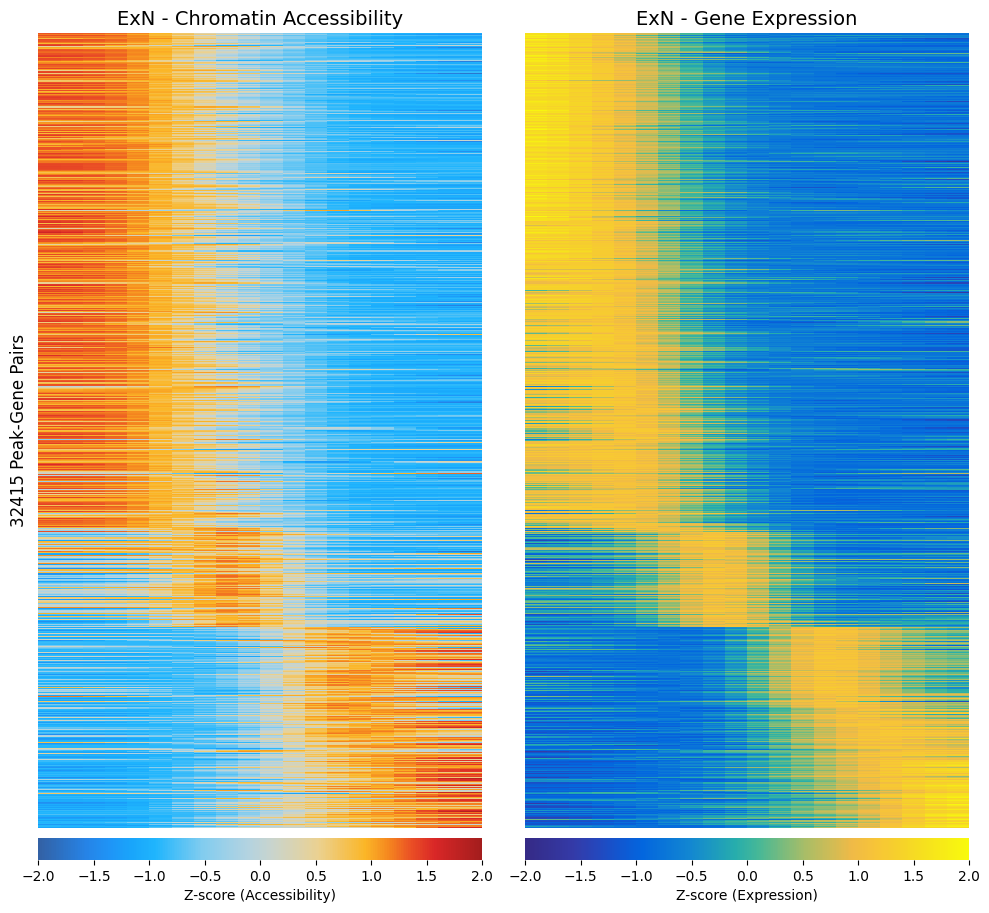


Processing Lineage: InN
  -> Found 33119 specific links (correlation > 0.5)
  -> Quality Filtering: Removed 13067 bad links.
  -> Final Links for plotting: 20052
  -> Links saved to CSV: ./outs/peak_gene_links_InN.csv
  -> Plot saved to: ./plot/peak_gene_dynamics_InN.pdf


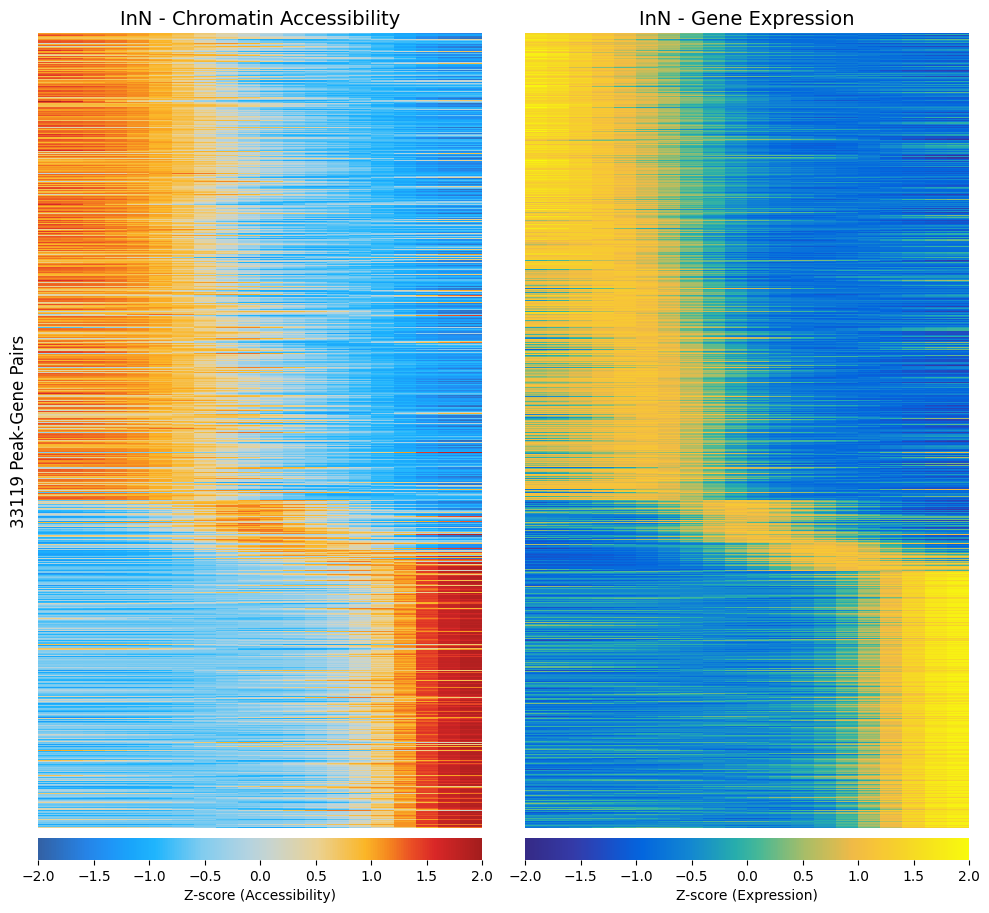


Processing Lineage: Oligo
  -> Found 45544 specific links (correlation > 0.5)
  -> Quality Filtering: Removed 9040 bad links.
  -> Final Links for plotting: 36504
  -> Links saved to CSV: ./outs/peak_gene_links_Oligo.csv
  -> Plot saved to: ./plot/peak_gene_dynamics_Oligo.pdf


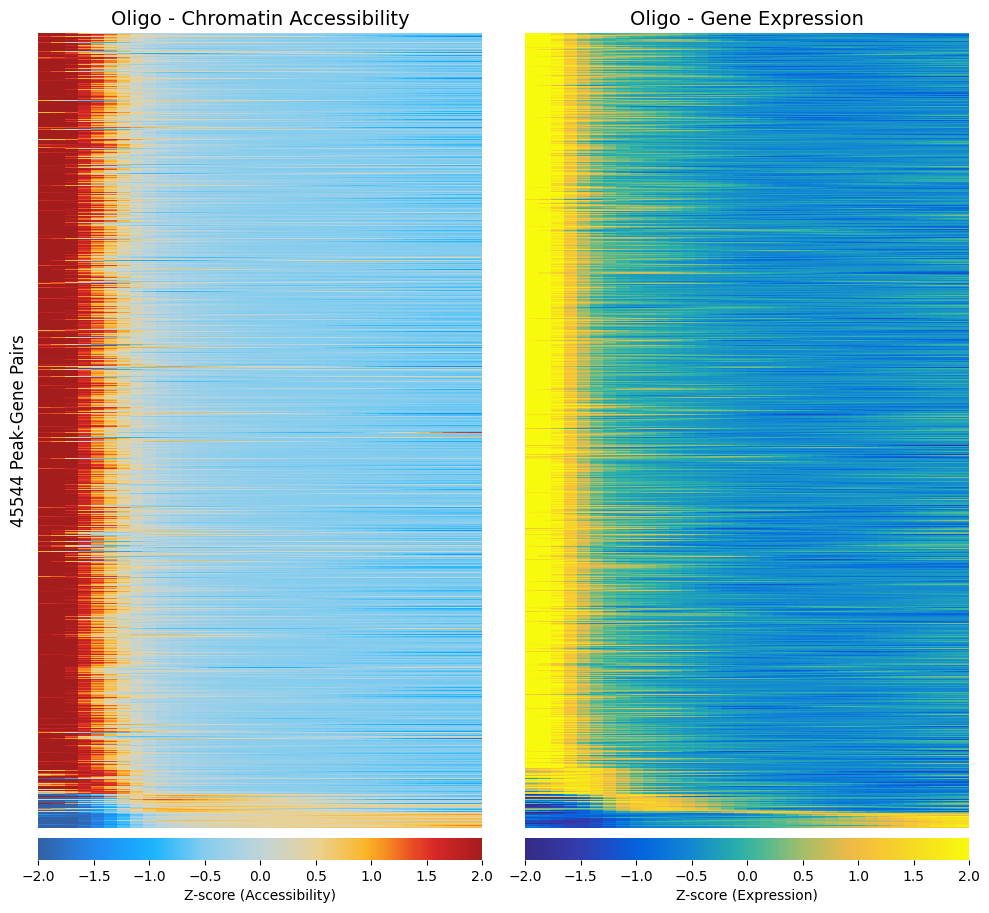


Processing Lineage: Astro
  -> Found 48386 specific links (correlation > 0.5)
  -> Quality Filtering: Removed 6442 bad links.
  -> Final Links for plotting: 41944
  -> Links saved to CSV: ./outs/peak_gene_links_Astro.csv
  -> Plot saved to: ./plot/peak_gene_dynamics_Astro.pdf


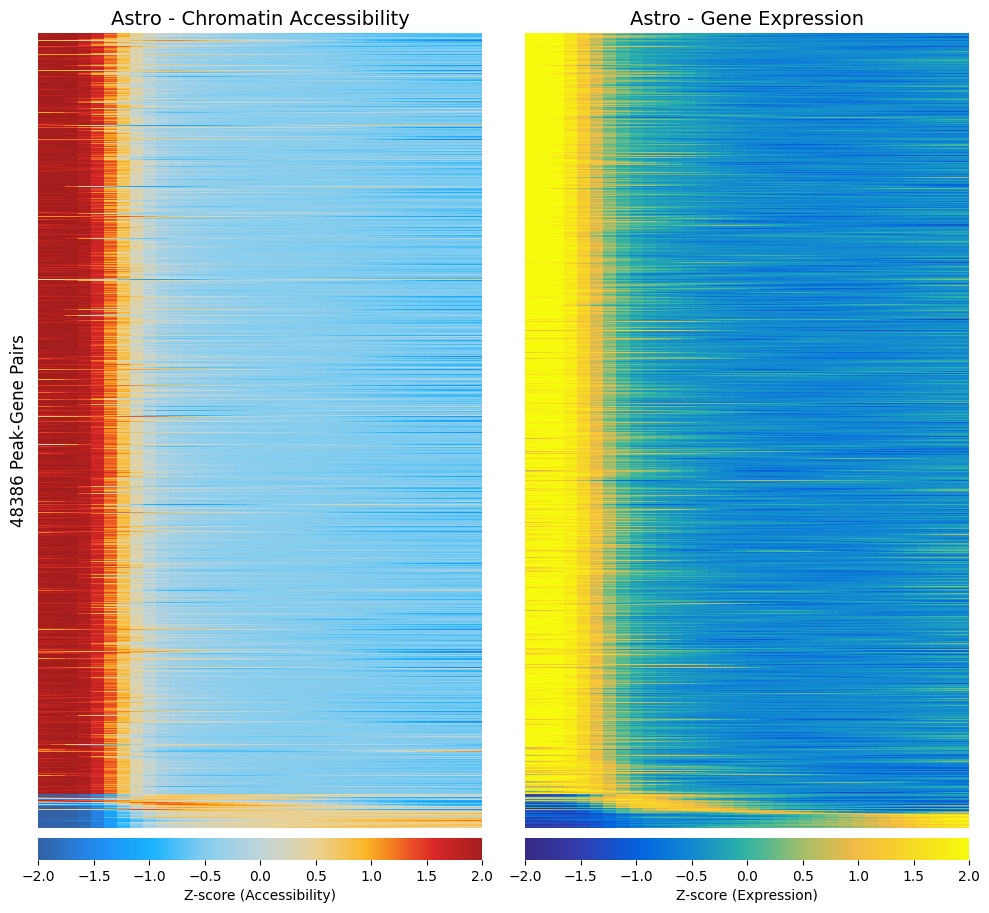

In [14]:

for lineage_name, order_list in lineage_dict.items():
    print(f"\n{'='*40}")
    print(f"Processing Lineage: {lineage_name}")
    
    # --- Step A: Refilter links ---
    lin_links, lin_rna, lin_atac = get_lineage_specific_links(
        region_filtered, rna_pb, atac_pb, order_list, min_corr=0.5
    )
    
    n_links = len(lin_links)
    print(f"  -> Found {n_links} specific links (correlation > 0.5)")
    
    # 1. RNA matrix for QC metrics
    temp_rna = lin_rna.loc[lin_links['target']].values
    temp_z = np.nan_to_num(zscore(temp_rna, axis=1))
    
    # --- Filter 1: signal strength ---
    # Low max Z-score => flat / noisy gene
    max_z_scores = np.max(temp_z, axis=1)
    keep_strong_signal = max_z_scores > 1.5 
    
    # --- Filter 2: peak consistency ---
    # Reduce late genes driven by noise ranking too high
    # Argmax (peak time bin)
    peak_indices = np.argmax(temp_z, axis=1)
    
    # Center of mass
    temp_pos = np.maximum(temp_z, 0)
    mass = np.sum(temp_pos, axis=1)
    mass[mass == 0] = 1e-9
    x_axis = np.arange(temp_z.shape[1])
    com_indices = np.sum(temp_pos * x_axis, axis=1) / mass
    
    # Large argmax–COM gap => odd profile / outlier spike
    # Allowed deviation ~25–30% of bins
    diff = np.abs(peak_indices - com_indices)
    keep_consistent = diff < 5.0  
    
    # --- Apply filters ---
    final_mask = keep_strong_signal & keep_consistent
    lin_links = lin_links[final_mask].copy()
    
    print(f"  -> Quality Filtering: Removed {np.sum(~final_mask)} bad links.")
    print(f"  -> Final Links for plotting: {len(lin_links)}")
    
    if len(lin_links) < 10:
        print("  -> Too few links after QC, skipping.")
        continue


    # --- Step B: Z-score and sort ---
    # Raw subset
    mat_rna_raw = lin_rna.loc[lin_links['target']].values
    mat_atac_raw = lin_atac.loc[lin_links['region']].values
    
    # Z-score along pseudotime axis
    mat_rna_z = np.nan_to_num(zscore(mat_rna_raw, axis=1))
    mat_atac_z = np.nan_to_num(zscore(mat_atac_raw, axis=1))
    
    # Sort by RNA expression peak time
    # Sort key: argmax
    peak_time_rna = np.argmax(mat_rna_z, axis=1)
    sorted_indices = np.argsort(peak_time_rna)
    
    mat_rna_sorted = mat_rna_z[sorted_indices, :]
    mat_atac_sorted = mat_atac_z[sorted_indices, :]
    
    # Save sorted links to CSV
    # Reorder rows to match heatmap
    lin_links_sorted = lin_links.iloc[sorted_indices].copy()
        
    # Save file
    csv_path = f"./outs/peak_gene_links_{lineage_name}.csv"
    lin_links_sorted.to_csv(csv_path, index=False, sep=',')
    print(f"  -> Links saved to CSV: {csv_path}")

    # Smoothing
    sigma_val = 2.0
    mat_rna_plot = gaussian_filter1d(mat_rna_sorted, sigma=sigma_val, axis=1)
    mat_atac_plot = gaussian_filter1d(mat_atac_sorted, sigma=sigma_val, axis=1)
    
    # --- Step C: Plot (same style as before) ---
    fig, axes = plt.subplots(1, 2, figsize=(10, 10), sharey=True)
    vmin, vmax = -2.0, 2.0

    # ATAC Plot
    sns.heatmap(mat_atac_plot, cmap=ATAC_cmap, vmin=vmin, vmax=vmax, 
                xticklabels=False, yticklabels=False, 
                cbar_kws={'label': 'Z-score (Accessibility)', 'location': 'bottom', 'pad':0.01},
                ax=axes[0],
                rasterized=True)
    axes[0].set_title(f'{lineage_name} - Chromatin Accessibility', fontsize=14)
    axes[0].set_xlabel('Pseudotime (Groups)', fontsize=12)
    axes[0].set_ylabel(f'{n_links} Peak-Gene Pairs', fontsize=12)

    # RNA Plot
    sns.heatmap(mat_rna_plot, cmap=RNA_cmap, vmin=vmin, vmax=vmax, 
                xticklabels=False, yticklabels=False, 
                cbar_kws={'label': 'Z-score (Expression)', 'location': 'bottom', 'pad':0.01},
                ax=axes[1],
                rasterized=True)
    axes[1].set_title(f'{lineage_name} - Gene Expression', fontsize=14)
    axes[1].set_xlabel('Pseudotime (Groups)', fontsize=12)

    plt.tight_layout()
    
    # Filename from lineage name
    save_path = f"./plot/peak_gene_dynamics_{lineage_name}.pdf"
    plt.savefig(save_path, dpi=300)
    print(f"  -> Plot saved to: {save_path}")
    
    plt.show()
    plt.close() # Close figure to free memory